# Deep FCNN on Tiny ImageNet
**Author**: Deadlyharbor aka Aman Gupta and Vansh Pandey

## Task Description - 3.1 & 3.2
- Dataset: Tiny ImageNet (10 classes subset)
- Model: Deep FCNN (8 layers)
- **Task 3.1** Experiments:
    - Exp A: Sigmoid, No Batch Norm
    - Exp B: Leaky ReLU (0.01), Batch Norm
- **Task 3.2** Switch-Off Tests:
    1. Remove Dropout
    2. Learning Rate: 10x higher & 10x lower
    3. Adam vs Vanilla SGD
- Optimizer: AdamW (except for SGD experiment)

## Expectations in 3.1
- Small gradient norms and VGP in sigmoid activation function as NN is deep
- Learning occurs while relu is used with batch normalization as there will be no VGP.
- FCNN is used for images so overfitting without dropout is expected in task 1.
- Simplifiying the network architecture to lesser n[l] per layer may also reduce overfitting 
- Speed of training in relu will be faster due to reduce exponential operations

In [29]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import pandas as pd

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check CUDA
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.6.0+cpu
CUDA Available: False


## 1. Data Parsing and Utils

In [30]:
def get_data_loaders(data_dir, batch_size=64):
    # Standard transformation for Tiny ImageNet (64x64)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Standard Tiny ImageNet structure: 'train' and 'val' folders
    train_dir = os.path.join(data_dir, 'tiny-imagenet', 'train')
    val_dir = os.path.join(data_dir, 'tiny-imagenet', 'val')
    
    if not os.path.exists(train_dir) or not os.path.exists(val_dir):
        print(f"Hey change this path carefully - {data_dir}/tiny-imagenet")
        return None, None

    # Load datasets directly from folders
    train_dataset = ImageFolder(root=train_dir, transform=transform)
    val_dataset = ImageFolder(root=val_dir, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    print(f"Classes: {train_dataset.classes}")
    print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
    
    return train_loader, val_loader

# Constants
DATA_DIR = 'C:\\Users\\Vansh\\Desktop\\DeepLearning-Project\\dataset'
BATCH_SIZE = 64
NUM_CLASSES = 10
INPUT_DIM = 64 * 64 * 3  # 12288

## 2. Network Architecture

In [31]:
class DeepFCNN(nn.Module):
    def __init__(self, activation='sigmoid', use_batch_norm=False, dropout_rate=0.0):
        super(DeepFCNN, self).__init__()
        self.use_batch_norm = use_batch_norm
        self.layers = nn.ModuleList()
        
        # Architecture: 12288 -> 512, 256, 256, 128, 128, 64, 32 -> 10
        dims = [INPUT_DIM, 512, 256, 256, 128, 128, 64, 32, NUM_CLASSES]
        
        for i in range(len(dims) - 1):
            self.layers.append(nn.Linear(dims[i], dims[i+1]))
            
            # Add activation and BN for all except last layer
            if i < len(dims) - 2:
                if use_batch_norm:
                    self.layers.append(nn.BatchNorm1d(dims[i+1]))
                
                if activation == 'sigmoid':
                    self.layers.append(nn.Sigmoid())
                elif activation == 'leaky_relu':
                    self.layers.append(nn.LeakyReLU(0.01))
                
                # Add dropout if specified
                if dropout_rate > 0:
                    self.layers.append(nn.Dropout(dropout_rate))
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        for layer in self.layers:
            x = layer(x)
        return x

## 3. Training Loop & Utils

In [32]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, optimizer_type='adam', device='cuda'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Select optimizer
    if optimizer_type == 'adam':
        optimizer = optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8)
    elif optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.0)  # Vanilla SGD
    
    history = {
        'train_loss': [], 'val_loss': [], 'val_acc': [],
        'layer1_grad_norm': [], 'time_per_epoch': []
    }
    
    print(f"Starting training on {device}...")
    
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        
        # Track gradient norm for first layer
        epoch_grad_norms = []
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Capture grad norm of first linear layer
            first_layer_grad = model.layers[0].weight.grad.norm().item()
            epoch_grad_norms.append(first_layer_grad)
            
            optimizer.step()
            running_loss += loss.item()
        
        epoch_time = time.time() - start_time
        avg_train_loss = running_loss / len(train_loader)
        avg_grad_norm = np.mean(epoch_grad_norms)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['layer1_grad_norm'].append(avg_grad_norm)
        history['time_per_epoch'].append(epoch_time)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Time: {epoch_time:.2f}s "
              f"Train Loss: {avg_train_loss:.4f} "
              f"Val Loss: {avg_val_loss:.4f} "
              f"Val Acc: {val_acc:.2f}% "
              f"Grad Norm: {avg_grad_norm:.4f}")
              
    return history

## 4. Task 3.1 - Run Experiments A & B

In [33]:
# Setup Data
train_loader, val_loader = get_data_loaders(DATA_DIR, BATCH_SIZE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if train_loader:
    # EXP A: Sigmoid, No Batch Norm
    print("\n--- Experiment A: Sigmoid ---")
    model_a = DeepFCNN(activation='sigmoid', use_batch_norm=False)
    history_a = train_model(model_a, train_loader, val_loader, epochs=20, device=device)

    # EXP B: Leaky ReLU + Batch Norm
    print("\n--- Experiment B: Leaky ReLU + BN ---")
    model_b = DeepFCNN(activation='leaky_relu', use_batch_norm=True)
    history_b = train_model(model_b, train_loader, val_loader, epochs=20, device=device)
else:
    print("Data loaders failed to initialize. Check path.")

Classes: ['n07871810', 'n07873807', 'n07875152', 'n07920052', 'n09193705', 'n09246464', 'n09256479', 'n09332890', 'n09428293', 'n12267677']
Train size: 3500, Val size: 500
Using device: cpu

--- Experiment A: Sigmoid ---
Starting training on cpu...
Epoch [1/20] Time: 11.69s Train Loss: 2.3070 Val Loss: 2.2829 Val Acc: 17.40% Grad Norm: 0.0005
Epoch [2/20] Time: 9.70s Train Loss: 2.1888 Val Loss: 2.0877 Val Acc: 18.60% Grad Norm: 0.0296
Epoch [3/20] Time: 12.47s Train Loss: 2.0437 Val Loss: 2.0633 Val Acc: 18.00% Grad Norm: 0.1760
Epoch [4/20] Time: 9.99s Train Loss: 1.9970 Val Loss: 2.0068 Val Acc: 19.20% Grad Norm: 0.0991
Epoch [5/20] Time: 10.76s Train Loss: 1.9727 Val Loss: 1.9889 Val Acc: 19.20% Grad Norm: 0.2260
Epoch [6/20] Time: 10.77s Train Loss: 1.9742 Val Loss: 2.0571 Val Acc: 19.00% Grad Norm: 0.1508
Epoch [7/20] Time: 10.33s Train Loss: 1.9845 Val Loss: 2.0219 Val Acc: 19.00% Grad Norm: 0.2022
Epoch [8/20] Time: 10.77s Train Loss: 1.9661 Val Loss: 1.9855 Val Acc: 18.00% Gra

## 5. Task 3.1 - Plot Results

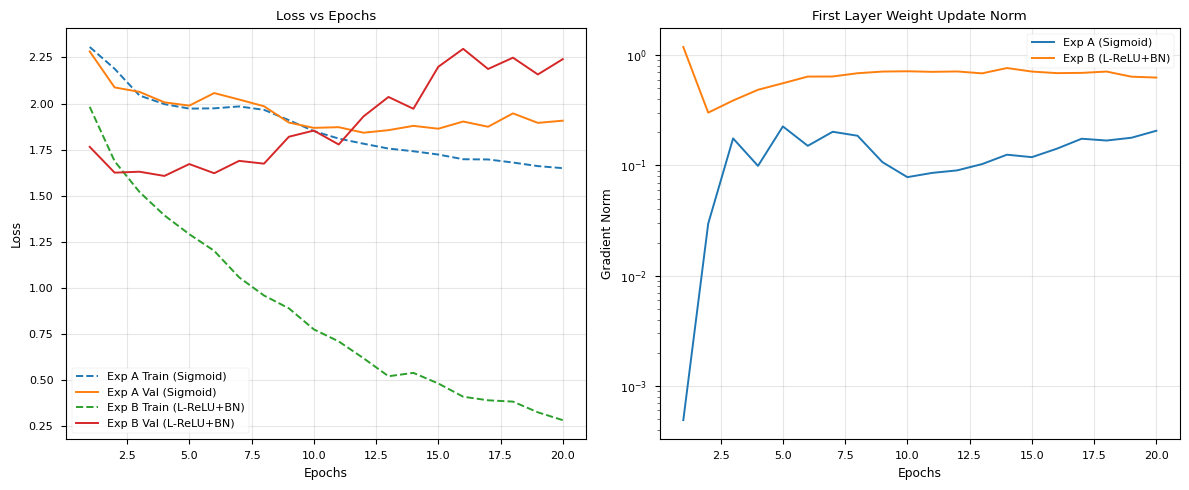

Task 3.1 Plots saved to plots/comparison_plot_3_1.png


In [34]:
os.makedirs('plots', exist_ok=True)

if train_loader:
    epochs = range(1, 21)

    # Plot Loss Comparison
    plt.figure(figsize=(12, 5))
    plt.style.use('seaborn-v0_8-paper')
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_a['train_loss'], label='Exp A Train (Sigmoid)', linestyle='--')
    plt.plot(epochs, history_a['val_loss'], label='Exp A Val (Sigmoid)')
    plt.plot(epochs, history_b['train_loss'], label='Exp B Train (L-ReLU+BN)', linestyle='--')
    plt.plot(epochs, history_b['val_loss'], label='Exp B Val (L-ReLU+BN)')
    plt.title('Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Gradient Norms
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_a['layer1_grad_norm'], label='Exp A (Sigmoid)')
    plt.plot(epochs, history_b['layer1_grad_norm'], label='Exp B (L-ReLU+BN)')
    plt.title('First Layer Weight Update Norm')
    plt.xlabel('Epochs')
    plt.ylabel('Gradient Norm')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('plots/comparison_plot_3_1.png', dpi=300)
    plt.show()
    
    print("Task 3.1 Plots saved to plots/comparison_plot_3_1.png")

# Task 3.2 - Switch-Off Tests

## Baseline Configuration (for comparison)
- Activation: Leaky ReLU (0.01)
- Batch Normalization: Yes
- Dropout: 0.3 (baseline)
- Learning Rate: 0.001
- Optimizer: AdamW

In [ ]:
switch_off_results = []

if train_loader: 
    print("BASELINE: L-ReLU + BN + Dropout(0.3) + LR=0.001 + Adam")
    model_baseline = DeepFCNN(activation='leaky_relu', use_batch_norm=True, dropout_rate=0.3)
    history_baseline = train_model(model_baseline, train_loader, val_loader, epochs=20, 
                                   lr=0.001, optimizer_type='adam', device=device)
    final_val_acc_baseline = history_baseline['val_acc'][-1]
    switch_off_results.append({
        'Configuration': 'Baseline (L-ReLU + BN + Dropout 0.3 + LR 0.001 + Adam)',
        'Final Val Acc (%)': f"{final_val_acc_baseline:.2f}"
    })
    print(f"Baseline Final Val Accuracy: {final_val_acc_baseline:.2f}%\n")


--- BASELINE: L-ReLU + BN + Dropout(0.3) + LR=0.001 + Adam ---
Starting training on cpu...
Epoch [1/20] Time: 10.06s Train Loss: 2.3149 Val Loss: 2.1294 Val Acc: 28.00% Grad Norm: 1.2177
Epoch [2/20] Time: 10.50s Train Loss: 2.1082 Val Loss: 1.9033 Val Acc: 33.40% Grad Norm: 0.2275
Epoch [3/20] Time: 11.08s Train Loss: 1.9295 Val Loss: 1.7367 Val Acc: 36.20% Grad Norm: 0.2056
Epoch [4/20] Time: 10.29s Train Loss: 1.7981 Val Loss: 1.6592 Val Acc: 35.60% Grad Norm: 0.2556
Epoch [5/20] Time: 10.04s Train Loss: 1.7228 Val Loss: 1.6750 Val Acc: 36.00% Grad Norm: 0.2954
Epoch [6/20] Time: 10.14s Train Loss: 1.6615 Val Loss: 1.6317 Val Acc: 36.20% Grad Norm: 0.3278
Epoch [7/20] Time: 10.73s Train Loss: 1.6034 Val Loss: 1.6096 Val Acc: 37.80% Grad Norm: 0.3558
Epoch [8/20] Time: 17.01s Train Loss: 1.6046 Val Loss: 1.6201 Val Acc: 37.40% Grad Norm: 0.3927
Epoch [9/20] Time: 19.22s Train Loss: 1.5243 Val Loss: 1.6153 Val Acc: 37.40% Grad Norm: 0.3901
Epoch [10/20] Time: 10.98s Train Loss: 1.506

## Switch-Off Test 1: Remove Dropout

In [ ]:
if train_loader:
    print("SWITCH-OFF Test 1: No Dropout")
    model_no_dropout = DeepFCNN(activation='leaky_relu', use_batch_norm=True, dropout_rate=0.0)
    history_no_dropout = train_model(model_no_dropout, train_loader, val_loader, epochs=20,
                                     lr=0.001, optimizer_type='adam', device=device)
    final_val_acc_no_dropout = history_no_dropout['val_acc'][-1]
    switch_off_results.append({
        'Configuration': 'No Dropout (L-ReLU + BN + LR 0.001 + Adam)',
        'Final Val Acc (%)': f"{final_val_acc_no_dropout:.2f}"
    })
    print(f"No Dropout Final Val Accuracy: {final_val_acc_no_dropout:.2f}%\n")


--- SWITCH-OFF Test 1: No Dropout ---
Starting training on cpu...
Epoch [1/20] Time: 8.77s Train Loss: 1.9763 Val Loss: 1.7764 Val Acc: 32.80% Grad Norm: 1.1663
Epoch [2/20] Time: 8.58s Train Loss: 1.6698 Val Loss: 1.6502 Val Acc: 35.60% Grad Norm: 0.3067
Epoch [3/20] Time: 8.59s Train Loss: 1.5139 Val Loss: 1.6316 Val Acc: 39.60% Grad Norm: 0.4049
Epoch [4/20] Time: 8.60s Train Loss: 1.4102 Val Loss: 1.6647 Val Acc: 41.00% Grad Norm: 0.4708
Epoch [5/20] Time: 8.53s Train Loss: 1.2958 Val Loss: 1.5919 Val Acc: 41.80% Grad Norm: 0.5576
Epoch [6/20] Time: 8.58s Train Loss: 1.1860 Val Loss: 1.7076 Val Acc: 40.20% Grad Norm: 0.5954
Epoch [7/20] Time: 8.85s Train Loss: 1.0792 Val Loss: 1.6875 Val Acc: 40.20% Grad Norm: 0.6605
Epoch [8/20] Time: 8.66s Train Loss: 0.9755 Val Loss: 1.7381 Val Acc: 42.40% Grad Norm: 0.7119
Epoch [9/20] Time: 8.59s Train Loss: 0.8974 Val Loss: 1.8698 Val Acc: 39.80% Grad Norm: 0.6890
Epoch [10/20] Time: 9.27s Train Loss: 0.7769 Val Loss: 1.7423 Val Acc: 42.00% 

## Switch-Off Test 2a: Learning Rate 10x Higher (0.01)

In [ ]:
if train_loader:
    print("SWITCH-OFF Test 2a: LR = 0.01 (10x higher)")
    model_lr_high = DeepFCNN(activation='leaky_relu', use_batch_norm=True, dropout_rate=0.3)
    history_lr_high = train_model(model_lr_high, train_loader, val_loader, epochs=20,
                                  lr=0.01, optimizer_type='adam', device=device)
    final_val_acc_lr_high = history_lr_high['val_acc'][-1]
    switch_off_results.append({
        'Configuration': 'LR = 0.01 (10x higher)',
        'Final Val Acc (%)': f"{final_val_acc_lr_high:.2f}"
    })
    print(f"LR 0.01 Final Val Accuracy: {final_val_acc_lr_high:.2f}%\n")


--- SWITCH-OFF Test 2a: LR = 0.01 (10x higher) ---
Starting training on cpu...
Epoch [1/20] Time: 8.53s Train Loss: 2.0828 Val Loss: 1.8582 Val Acc: 27.60% Grad Norm: 0.5278
Epoch [2/20] Time: 8.54s Train Loss: 1.8419 Val Loss: 1.7270 Val Acc: 29.40% Grad Norm: 0.0368
Epoch [3/20] Time: 8.77s Train Loss: 1.7700 Val Loss: 1.7251 Val Acc: 29.60% Grad Norm: 0.0426
Epoch [4/20] Time: 8.76s Train Loss: 1.7158 Val Loss: 1.6290 Val Acc: 36.00% Grad Norm: 0.0573
Epoch [5/20] Time: 8.63s Train Loss: 1.6847 Val Loss: 1.6522 Val Acc: 33.20% Grad Norm: 0.0615
Epoch [6/20] Time: 8.57s Train Loss: 1.6499 Val Loss: 1.6129 Val Acc: 34.20% Grad Norm: 0.0628
Epoch [7/20] Time: 8.47s Train Loss: 1.5997 Val Loss: 1.6072 Val Acc: 37.00% Grad Norm: 0.0740
Epoch [8/20] Time: 8.95s Train Loss: 1.5950 Val Loss: 1.6069 Val Acc: 36.80% Grad Norm: 0.0745
Epoch [9/20] Time: 8.67s Train Loss: 1.5725 Val Loss: 1.6384 Val Acc: 35.40% Grad Norm: 0.0724
Epoch [10/20] Time: 9.06s Train Loss: 1.5214 Val Loss: 1.6233 Val

## Switch-Off Test 2b: Learning Rate 10x Lower (0.0001)

In [ ]:
if train_loader:
    print("SWITCH-OFF Test 2b: LR = 0.0001 (10x lower)")
    model_lr_low = DeepFCNN(activation='leaky_relu', use_batch_norm=True, dropout_rate=0.3)
    history_lr_low = train_model(model_lr_low, train_loader, val_loader, epochs=20,
                                 lr=0.0001, optimizer_type='adam', device=device)
    final_val_acc_lr_low = history_lr_low['val_acc'][-1]
    switch_off_results.append({
        'Configuration': 'LR = 0.0001 (10x lower)',
        'Final Val Acc (%)': f"{final_val_acc_lr_low:.2f}"
    })
    print(f"LR 0.0001 Final Val Accuracy: {final_val_acc_lr_low:.2f}%\n")


--- SWITCH-OFF Test 2b: LR = 0.0001 (10x lower) ---
Starting training on cpu...
Epoch [1/20] Time: 8.72s Train Loss: 2.3955 Val Loss: 2.2851 Val Acc: 13.40% Grad Norm: 9.4464
Epoch [2/20] Time: 8.48s Train Loss: 2.3507 Val Loss: 2.2503 Val Acc: 14.00% Grad Norm: 5.0523
Epoch [3/20] Time: 8.54s Train Loss: 2.3059 Val Loss: 2.2178 Val Acc: 17.20% Grad Norm: 4.0101
Epoch [4/20] Time: 8.48s Train Loss: 2.2754 Val Loss: 2.1861 Val Acc: 21.20% Grad Norm: 3.4204
Epoch [5/20] Time: 9.20s Train Loss: 2.2447 Val Loss: 2.1538 Val Acc: 23.20% Grad Norm: 2.8924
Epoch [6/20] Time: 8.51s Train Loss: 2.2198 Val Loss: 2.1206 Val Acc: 28.60% Grad Norm: 2.5765
Epoch [7/20] Time: 8.56s Train Loss: 2.1922 Val Loss: 2.0922 Val Acc: 29.20% Grad Norm: 2.3136
Epoch [8/20] Time: 8.68s Train Loss: 2.1601 Val Loss: 2.0547 Val Acc: 30.80% Grad Norm: 2.0468
Epoch [9/20] Time: 8.78s Train Loss: 2.1169 Val Loss: 2.0279 Val Acc: 32.60% Grad Norm: 1.8251
Epoch [10/20] Time: 8.56s Train Loss: 2.0919 Val Loss: 2.0058 Va

## Switch-Off Test 3: Adam vs Vanilla SGD

In [ ]:
if train_loader:
    print("SWITCH-OFF Test 3: Vanilla SGD (no momentum)")
    model_sgd = DeepFCNN(activation='leaky_relu', use_batch_norm=True, dropout_rate=0.3)
    history_sgd = train_model(model_sgd, train_loader, val_loader, epochs=20,
                             lr=0.001, optimizer_type='sgd', device=device)
    final_val_acc_sgd = history_sgd['val_acc'][-1]
    switch_off_results.append({
        'Configuration': 'Vanilla SGD (L-ReLU + BN + Dropout 0.3 + LR 0.001)',
        'Final Val Acc (%)': f"{final_val_acc_sgd:.2f}"
    })
    print(f"Vanilla SGD Final Val Accuracy: {final_val_acc_sgd:.2f}%\n")


--- SWITCH-OFF Test 3: Vanilla SGD (no momentum) ---
Starting training on cpu...
Epoch [1/20] Time: 7.39s Train Loss: 2.3958 Val Loss: 2.2996 Val Acc: 11.20% Grad Norm: 24.3646
Epoch [2/20] Time: 7.16s Train Loss: 2.3820 Val Loss: 2.2936 Val Acc: 10.80% Grad Norm: 22.3808
Epoch [3/20] Time: 7.09s Train Loss: 2.3790 Val Loss: 2.2867 Val Acc: 12.80% Grad Norm: 20.2442
Epoch [4/20] Time: 7.06s Train Loss: 2.3649 Val Loss: 2.2809 Val Acc: 12.60% Grad Norm: 19.4577
Epoch [5/20] Time: 7.40s Train Loss: 2.3665 Val Loss: 2.2742 Val Acc: 13.40% Grad Norm: 18.4925
Epoch [6/20] Time: 7.14s Train Loss: 2.3340 Val Loss: 2.2661 Val Acc: 13.60% Grad Norm: 17.7634
Epoch [7/20] Time: 7.48s Train Loss: 2.3267 Val Loss: 2.2610 Val Acc: 15.20% Grad Norm: 17.2501
Epoch [8/20] Time: 7.00s Train Loss: 2.3328 Val Loss: 2.2644 Val Acc: 15.00% Grad Norm: 16.4548
Epoch [9/20] Time: 7.06s Train Loss: 2.3149 Val Loss: 2.2522 Val Acc: 17.40% Grad Norm: 15.7187
Epoch [10/20] Time: 7.07s Train Loss: 2.3107 Val Loss:

## Summary Table for Switch-Off Tests

In [ ]:
if train_loader: 
    df_results = pd.DataFrame(switch_off_results)
    print("\n" + "="*80)
    print("TASK 3.2 - SWITCH-OFF TESTS SUMMARY")
    print("="*80)
    print(df_results.to_string(index=False))
    print("="*80)
     
    df_results.to_csv('plots/switch_off_results.csv', index=False)
    print("\nResults saved to plots/switch_off_results.csv")


TASK 3.2 - SWITCH-OFF TESTS SUMMARY
                                         Configuration Final Val Acc (%)
Baseline (L-ReLU + BN + Dropout 0.3 + LR 0.001 + Adam)             42.00
            No Dropout (L-ReLU + BN + LR 0.001 + Adam)             41.20
                                LR = 0.01 (10x higher)             38.20
                               LR = 0.0001 (10x lower)             33.60
    Vanilla SGD (L-ReLU + BN + Dropout 0.3 + LR 0.001)             23.80

Results saved to plots/switch_off_results.csv


## Comparative Plots for Task 3.2

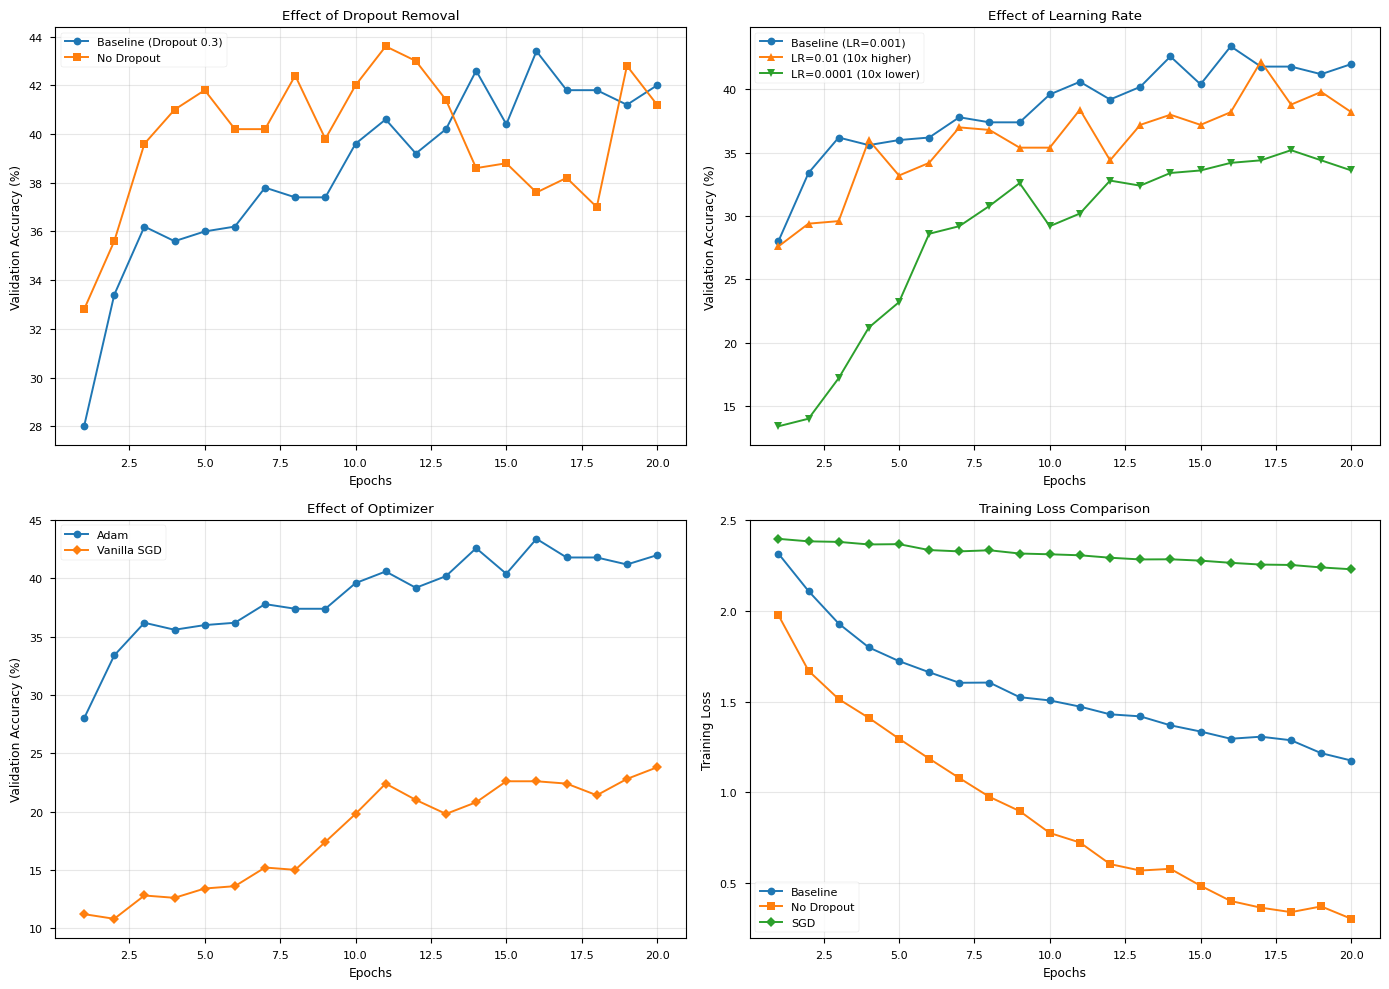

Switch-Off comparison plots saved to plots/switch_off_comparison.png


In [ ]:
if train_loader:
    epochs = range(1, 21)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plt.style.use('seaborn-v0_8-paper')
     
    axes[0, 0].plot(epochs, history_baseline['val_acc'], label='Baseline (Dropout 0.3)', marker='o')
    axes[0, 0].plot(epochs, history_no_dropout['val_acc'], label='No Dropout', marker='s')
    axes[0, 0].set_title('Effect of Dropout Removal')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Validation Accuracy (%)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
     
    axes[0, 1].plot(epochs, history_baseline['val_acc'], label='Baseline (LR=0.001)', marker='o')
    axes[0, 1].plot(epochs, history_lr_high['val_acc'], label='LR=0.01 (10x higher)', marker='^')
    axes[0, 1].plot(epochs, history_lr_low['val_acc'], label='LR=0.0001 (10x lower)', marker='v')
    axes[0, 1].set_title('Effect of Learning Rate')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Validation Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
     
    axes[1, 0].plot(epochs, history_baseline['val_acc'], label='Adam', marker='o')
    axes[1, 0].plot(epochs, history_sgd['val_acc'], label='Vanilla SGD', marker='D')
    axes[1, 0].set_title('Effect of Optimizer')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Validation Accuracy (%)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
     
    axes[1, 1].plot(epochs, history_baseline['train_loss'], label='Baseline', marker='o')
    axes[1, 1].plot(epochs, history_no_dropout['train_loss'], label='No Dropout', marker='s')
    axes[1, 1].plot(epochs, history_sgd['train_loss'], label='SGD', marker='D')
    axes[1, 1].set_title('Training Loss Comparison')
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('Training Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/switch_off_comparison.png', dpi=300)
    plt.show()
    
    print("Switch-Off comparison plots saved to plots/switch_off_comparison.png")